<a href="https://colab.research.google.com/github/Satishherakal/XAI_LABS/blob/main/LAB6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name:** Satish Herakal
**USN:** 1RUB25CSE0017

# 🧪 Lab: Write Your Own Explainable AI (XAI) Methods

**Dataset:** BloodMNIST: coloured microscope images of blood cells, 8 classes, 64 × 64 pixels  
**Model:** a small CNN (given to you)  
**Your job:** write the code for 7 XAI methods, then measure how good they are.

| Task | What you write | Marks |
|---|---|---|
| 1 | Saliency Map | 4 |
| 2 | Guided Backpropagation | 4 |
| 3 | CAM | 4 |
| 4 | Grad-CAM | 4 |
| 5 | Grad-CAM++ | 4 |
| 6 | LIME | 4 |
| 7 | SHAP | 4 |
| 8 | Side-by-side comparison figure | 2 |
| 9 | Quantitative evaluation (Deletion, Insertion, Average Drop) | 10 |
| 10 | Written questions | 10 |
| **Total** | | **50** |

### Rules
- The cells marked **GIVEN** are ready. Just run them.
- Write your code where you see `# YOUR CODE HERE`. Do not change the function names or inputs.
- Every XAI function must return a **NumPy heatmap of shape (64, 64) with values between 0 and 1**.
- After each task, run the **CHECK** cell. If it prints ✅, your output has the right shape.
- Use Google Colab with a GPU (Runtime → Change runtime type → GPU). A CPU also works, but it is slower.
- **Submit:** `RollNo_Name_XAI_Lab.ipynb` with all outputs shown.

## Part A — Setup (GIVEN)

In [1]:
!pip install -q medmnist lime shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.0 MB/s eta 0:00:00


In [2]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
import medmnist
from medmnist import INFO

torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


### Load BloodMNIST (GIVEN)

8 blood-cell classes: basophil, eosinophil, erythroblast, immature granulocytes, lymphocyte, monocyte, neutrophil, platelet.

100%|██████████| 156M/156M [01:33<00:00, 1.68MB/s]


11959 train | 3421 test | ['basophil', 'eosinophil', 'erythroblast', 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']


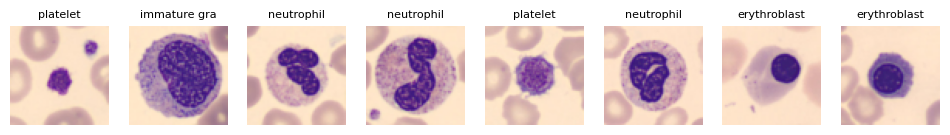

In [3]:
IMG_SIZE = 64
info = INFO["bloodmnist"]
class_names = [info["label"][str(i)] for i in range(len(info["label"]))]
num_classes = len(class_names)

transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize([0.5] * 3, [0.5] * 3)])   # pixels -> [-1, 1]

train_ds = medmnist.BloodMNIST(split="train", transform=transform, download=True, size=IMG_SIZE)
test_ds  = medmnist.BloodMNIST(split="test",  transform=transform, download=True, size=IMG_SIZE)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_ds,  batch_size=256)
print(len(train_ds), "train |", len(test_ds), "test |", class_names)

def to_image(t):
    # normalised tensor (3,H,W) -> image (H,W,3) in [0,1] for plotting
    return np.clip(t.detach().cpu().numpy().transpose(1, 2, 0) * 0.5 + 0.5, 0, 1)

plt.figure(figsize=(12, 2))
for i in range(8):
    img, lab = train_ds[i]
    plt.subplot(1, 8, i + 1); plt.imshow(to_image(img)); plt.title(class_names[int(lab[0])][:12], fontsize=8); plt.axis("off")
plt.show()

### A small CNN (GIVEN)

```
Input (3×64×64)
 → Conv 32 → ReLU → MaxPool      (32×32)
 → Conv 64 → ReLU → MaxPool      (16×16)
 → Conv 128 → ReLU               (16×16)   ← model.features  (last conv feature maps A^k)
 → Global Average Pooling        (128)
 → fc: Linear(128 → 8)                     ← model.fc  (weights w_k^c used by CAM)
```

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(128, n_classes)

    def forward(self, x):
        return self.fc(self.gap(self.features(x)).flatten(1))

model = SimpleCNN(num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(5):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.squeeze(1).long().to(device)
        optimizer.zero_grad()
        loss = F.cross_entropy(model(xb), yb)
        loss.backward()
        optimizer.step()
    print(f"epoch {epoch+1}  loss {loss.item():.3f}")

model.eval()
with torch.no_grad():
    correct = sum((model(xb.to(device)).argmax(1).cpu() == yb.squeeze(1)).sum().item() for xb, yb in test_loader)
print(f"Test accuracy: {100 * correct / len(test_ds):.1f}%")

epoch 1  loss 1.345
epoch 2  loss 0.862
epoch 3  loss 0.666
epoch 4  loss 0.736
epoch 5  loss 0.702
Test accuracy: 81.3%


### Pick one image and some helpers (GIVEN)

In [5]:
labels = test_ds.labels.squeeze()
idx = 0
x = test_ds[idx][0].unsqueeze(0).to(device)       # (1, 3, 64, 64)
image = to_image(x[0])
with torch.no_grad():
    probs = F.softmax(model(x), 1)[0]
pred_class = int(probs.argmax())
print("True:", class_names[labels[idx]], "| Predicted:", class_names[pred_class], f"({probs[pred_class].item():.2f})")

def normalize(a):
    a = np.asarray(a, dtype=np.float32)
    a = a - a.min()
    return a / (a.max() + 1e-8)

def upsample(t):
    # small torch map (h, w) -> numpy (64, 64) in [0, 1]
    t = torch.as_tensor(t, dtype=torch.float32).detach().cpu()
    return normalize(F.interpolate(t[None, None], size=(IMG_SIZE, IMG_SIZE), mode="bilinear")[0, 0].numpy())

def show(heat, title):
    plt.figure(figsize=(7, 2.5))
    plt.subplot(1, 3, 1); plt.imshow(image); plt.title("Image"); plt.axis("off")
    plt.subplot(1, 3, 2); plt.imshow(heat, cmap="jet"); plt.title(title); plt.axis("off")
    plt.subplot(1, 3, 3); plt.imshow(image); plt.imshow(heat, cmap="jet", alpha=0.5); plt.title("Overlay"); plt.axis("off")
    plt.show()

def check(heat, name):
    ok = isinstance(heat, np.ndarray) and heat.shape == (IMG_SIZE, IMG_SIZE) and heat.min() >= 0 and heat.max() <= 1 + 1e-6
    print(("✅ " if ok else "❌ ") + name + (" looks correct" if ok else " must return a (64, 64) numpy array in [0, 1]"))
    if ok: show(heat, name)

# Hook helper: get the feature maps A (128,16,16) and their gradients G for class `cls`
def get_A_and_G(m, x, cls):
    store = {}
    def hook(module, inp, out):
        store["A"] = out
        out.register_hook(lambda g: store.update(G=g))
    h = m.features.register_forward_hook(hook)
    m.zero_grad()
    m(x)[0, cls].backward()
    h.remove()
    return store["A"][0].detach(), store["G"][0].detach()

True: immature granulocytes(myelocytes, metamyelocytes and promyelocytes) | Predicted: immature granulocytes(myelocytes, metamyelocytes and promyelocytes) (0.54)


---
## Part B: Write the XAI methods

### Task 1: Saliency Map (4 marks)
$$\text{Saliency}(i,j) = \max_{c}\left|\frac{\partial y^{cls}}{\partial x_{c,i,j}}\right|$$
**Steps:** (1) copy `x` and make it require gradients, (2) forward pass and take the score of `cls`, (3) `backward()`, (4) take the absolute value of the input gradient, then the max over the 3 colour channels, (5) `normalize`.

✅ Saliency looks correct


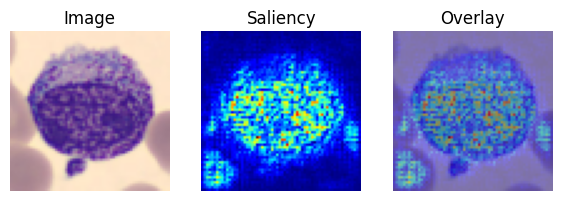

In [6]:
def saliency(m, x, cls):
    x_in = x.clone().requires_grad_(True)
    m.zero_grad()
    score = m(x_in)[0, cls]
    score.backward()
    heat = x_in.grad[0].abs().max(dim=0)[0].cpu().numpy()
    return normalize(heat)

check(saliency(model, x, pred_class), "Saliency")

### Task 2: Guided Backpropagation (4 marks)
Like saliency, but at every ReLU only **positive** gradients may flow backwards.

**Steps:** (1) make a copy of the model with `copy.deepcopy`, (2) on every `nn.ReLU` register a **full backward hook** that returns `(torch.clamp(grad_in[0], min=0),)`, (3) compute the input gradient as in Task 1, (4) abs, max over channels, normalize.

✅ Guided Backprop looks correct


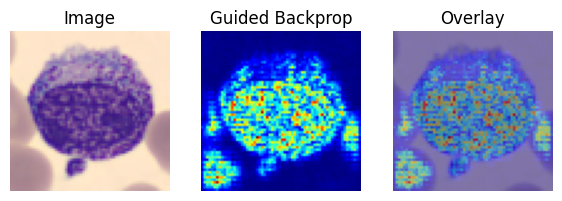

In [7]:
def guided_backprop(m, x, cls):
    gm = copy.deepcopy(m)

    def guided_relu_hook(module, grad_in, grad_out):
        return (torch.clamp(grad_in[0], min=0),)

    for mod in gm.modules():
        if isinstance(mod, nn.ReLU):
            mod.inplace = False
            mod.register_full_backward_hook(guided_relu_hook)

    x_in = x.clone().requires_grad_(True)
    gm.zero_grad()
    gm(x_in)[0, cls].backward()
    heat = x_in.grad[0].abs().max(dim=0)[0].cpu().numpy()
    return normalize(heat)

check(guided_backprop(model, x, pred_class), "Guided Backprop")

### Task 3: CAM (4 marks)
$$\text{CAM}^{c} = \text{ReLU}\Big(\sum_k w_k^{c} A^k\Big)$$
**Steps:** (1) get `A` from `get_A_and_G`, (2) take the weights `m.fc.weight[cls]` (shape 128), (3) weighted sum over the 128 maps, (4) ReLU, (5) `upsample` to 64 × 64.

✅ CAM looks correct


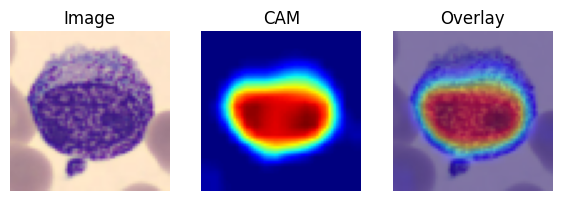

In [8]:
def cam(m, x, cls):
    A, _ = get_A_and_G(m, x, cls)
    w = m.fc.weight[cls].detach()
    heat = F.relu((w[:, None, None] * A).sum(0))
    return upsample(heat)

check(cam(model, x, pred_class), "CAM")

### Task 4: Grad-CAM (4 marks)
$$\alpha_k^c = \frac{1}{Z}\sum_{i,j}\frac{\partial y^c}{\partial A^k_{ij}} \qquad \text{Grad-CAM}^c = \text{ReLU}\Big(\sum_k \alpha_k^c A^k\Big)$$
**Steps:** (1) get `A, G`, (2) `alpha` = mean of `G` over height and width, (3) weighted sum, ReLU, upsample.

✅ Grad-CAM looks correct


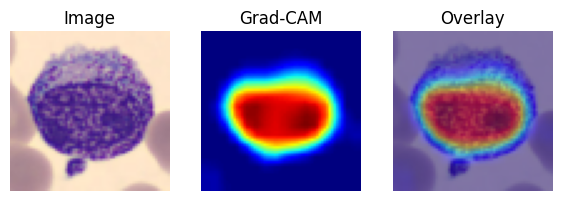

In [9]:
def grad_cam(m, x, cls):
    A, G = get_A_and_G(m, x, cls)
    alpha = G.mean(dim=(1, 2))
    heat = F.relu((alpha[:, None, None] * A).sum(0))
    return upsample(heat)

check(grad_cam(model, x, pred_class), "Grad-CAM")

### Task 5: Grad-CAM++ (4 marks)
$$a_{ij}^{k} = \frac{g_{ij}^2}{2g_{ij}^2 + \sum_{a,b}A^k_{ab}\,g_{ij}^3}\qquad w_k^c = \sum_{i,j} a^k_{ij}\,\text{ReLU}(g_{ij}) \qquad \text{Grad-CAM++}^c=\text{ReLU}\Big(\sum_k w_k^c A^k\Big)$$
(add `1e-8` to the denominator to avoid division by zero)

✅ Grad-CAM++ looks correct


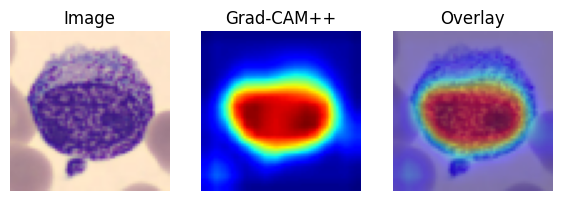

In [10]:
def grad_cam_pp(m, x, cls):
    A, G = get_A_and_G(m, x, cls)
    g2, g3 = G ** 2, G ** 3
    sum_A = A.sum(dim=(1, 2), keepdim=True)
    a = g2 / (2 * g2 + sum_A * g3 + 1e-8)
    w = (a * F.relu(G)).sum(dim=(1, 2))
    heat = F.relu((w[:, None, None] * A).sum(0))
    return upsample(heat)

check(grad_cam_pp(model, x, pred_class), "Grad-CAM++")

### Task 6: LIME (4 marks)
**Steps:**
1. Write `predict_fn(images)`. It gets a NumPy batch `(N, 64, 64, 3)` in [0, 1] and must return class **probabilities** `(N, 8)`. Hint: apply `transform` to each image, stack them, run the model, then softmax.
2. Call `lime_image.LimeImageExplainer().explain_instance(...)` with `labels=(cls,)`, `top_labels=None`, `num_samples=500`, `segmentation_fn=segmenter`, `random_seed=0`.
3. Make a heatmap: every superpixel gets its **positive** LIME weight. Hint: `weights = dict(exp.local_exp[cls])`, and `exp.segments` tells you which superpixel each pixel belongs to.

  0%|          | 0/500 [00:00<?, ?it/s]

✅ LIME looks correct


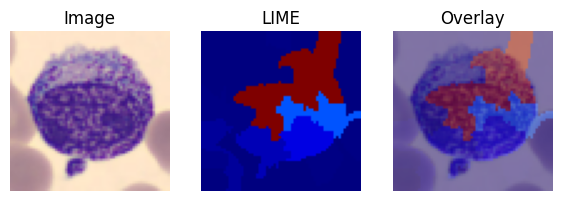

In [11]:
from lime import lime_image
from lime.wrappers.scikit_image import SegmentationAlgorithm
segmenter = SegmentationAlgorithm("slic", n_segments=50, compactness=10)

def lime_explain(m, x, cls):
    def predict_fn(images):
        batch = torch.stack([transform(img.astype(np.float32)) for img in images]).to(device)
        with torch.no_grad():
            return F.softmax(m(batch), dim=1).cpu().numpy()

    img = to_image(x[0])
    exp = lime_image.LimeImageExplainer().explain_instance(
        img.astype(np.double), predict_fn, labels=(cls,), top_labels=None,
        num_samples=500, segmentation_fn=segmenter, random_seed=0)

    weights = dict(exp.local_exp[cls])
    heat = np.vectorize(lambda s: max(weights.get(s, 0), 0))(exp.segments).astype(np.float32)
    return normalize(heat)

check(lime_explain(model, x, pred_class), "LIME")

### Task 7: SHAP (4 marks)
**Steps:**
1. Make a `background` tensor from 50 training images.
2. `shap.GradientExplainer(m, background).shap_values(x, nsamples=100)`
3. Pick the values of class `cls`. **Careful:** new SHAP versions return shape `(1, 3, H, W, classes)`, older ones return a list `(classes)[1, 3, H, W]`.
4. Sum over the 3 colour channels, keep only positive values, normalize.

✅ SHAP looks correct


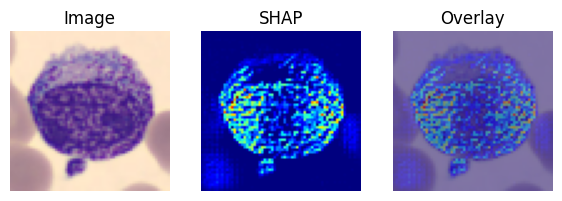

In [12]:
import shap
background = torch.stack([train_ds[i][0] for i in range(50)]).to(device)

def shap_explain(m, x, cls):
    sv = np.array(shap.GradientExplainer(m, background).shap_values(x, nsamples=100))
    if sv.shape[-1] == num_classes:      # (1, 3, H, W, classes)
        sv_class = sv[0, ..., cls]
    else:                                # (classes, 1, 3, H, W)
        sv_class = sv[cls, 0]
    heat = np.maximum(sv_class.sum(axis=0), 0)
    return normalize(heat)

check(shap_explain(model, x, pred_class), "SHAP")

### Task 8: Compare all methods (2 marks)
Make **one figure with 8 panels**: the original image and the 7 heatmaps (overlaid on the image), each with a title.

In [13]:
METHODS = {"Saliency": saliency, "Guided BP": guided_backprop, "CAM": cam, "Grad-CAM": grad_cam,
           "Grad-CAM++": grad_cam_pp, "LIME": lime_explain, "SHAP": shap_explain}

  0%|          | 0/500 [00:00<?, ?it/s]

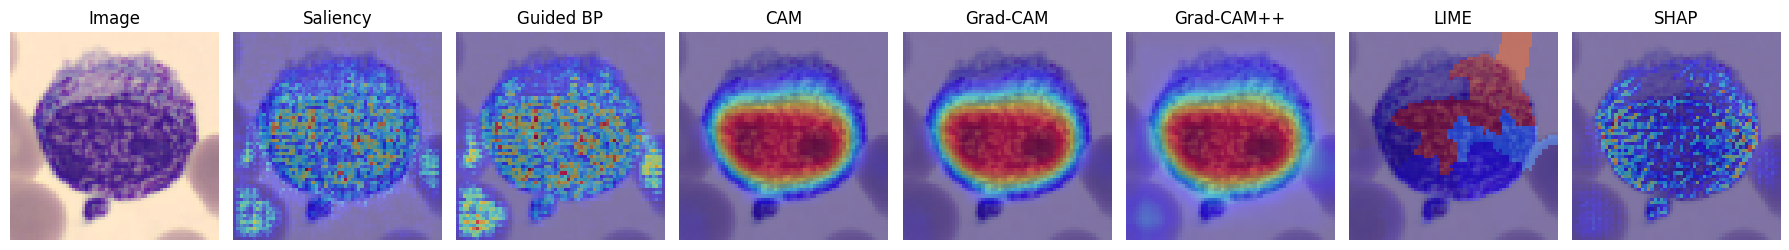

In [14]:
fig, axes = plt.subplots(1, 8, figsize=(18, 3))
axes[0].imshow(image); axes[0].set_title("Image"); axes[0].axis("off")
for i, (name, fn) in enumerate(METHODS.items()):
    heat = fn(model, x, pred_class)
    axes[i + 1].imshow(image)
    axes[i + 1].imshow(heat, cmap="jet", alpha=0.5)
    axes[i + 1].set_title(name)
    axes[i + 1].axis("off")
plt.tight_layout()
plt.show()

---
## Part C: Quantitative evaluation (10 marks)

### Task 9a: Deletion and Insertion AUC (4 marks)
Sort the pixels from **most** to **least** important (using the heatmap). In `steps = 20` steps:
- **Deletion:** set the top $k\%$ of pixels to 0 (the mean colour) and record the probability of `cls`. **Lower AUC is better.**
- **Insertion:** start from a **blurred** image and paste back the top $k\%$ original pixels. **Higher AUC is better.**

AUC = mean of the probabilities (trapezoid rule: `((p[:-1] + p[1:]) / 2).mean()`).  
Blur hint: `transforms.functional.gaussian_blur(x, kernel_size=15, sigma=5)`.

In [15]:
def deletion_insertion(m, x, heat, cls, steps=20):
    order = torch.as_tensor(np.argsort(-heat.flatten()).copy(), device=device)
    n = heat.size
    blurred = transforms.functional.gaussian_blur(x, kernel_size=15, sigma=5)

    del_imgs, ins_imgs = [], []
    for i in range(steps + 1):
        mask = torch.zeros(n, device=device)
        mask[order[: int(n * i / steps)]] = 1
        mask = mask.view(1, 1, IMG_SIZE, IMG_SIZE)
        del_imgs.append(x * (1 - mask))
        ins_imgs.append(blurred * (1 - mask) + x * mask)

    with torch.no_grad():
        p_del = F.softmax(m(torch.cat(del_imgs)), 1)[:, cls].cpu().numpy()
        p_ins = F.softmax(m(torch.cat(ins_imgs)), 1)[:, cls].cpu().numpy()

    del_auc = float(((p_del[:-1] + p_del[1:]) / 2).mean())
    ins_auc = float(((p_ins[:-1] + p_ins[1:]) / 2).mean())
    return del_auc, ins_auc

print(deletion_insertion(model, x, grad_cam(model, x, pred_class), pred_class))

(0.0501890555024147, 0.5505084991455078)


### Task 9b: Average Drop (2 marks)
Keep only the explained region: $x' = x \odot M$ (multiply the image by the heatmap).
With $Y$ = original probability and $O$ = probability on $x'$:
$$\text{Drop} = 100\cdot\frac{\max(0, Y-O)}{Y}\qquad(\text{lower is better})$$

In [16]:
def average_drop(m, x, heat, cls):
    with torch.no_grad():
        Y = F.softmax(m(x), 1)[0, cls].item()
        x_masked = x * torch.as_tensor(heat, dtype=torch.float32, device=device)
        O = F.softmax(m(x_masked), 1)[0, cls].item()
    drop = 100 * max(0, Y - O) / Y
    return drop

print(average_drop(model, x, grad_cam(model, x, pred_class), pred_class))

5.421731077738694


### Task 9c: Evaluate on 20 test images (4 marks)
For 20 test images and every method: compute the heatmap for the **predicted** class, then Deletion AUC, Insertion AUC and Average Drop.
Show a table of the **mean** for each method, and a bar chart for each metric.

In [17]:
N_IMAGES = 20
rows = []
for idx in range(N_IMAGES):
    xk = test_ds[idx][0].unsqueeze(0).to(device)
    with torch.no_grad():
        cls = int(model(xk).argmax())
    for name, fn in METHODS.items():
        heat = fn(model, xk, cls)
        d_auc, i_auc = deletion_insertion(model, xk, heat, cls)
        drop = average_drop(model, xk, heat, cls)
        rows.append({"Method": name, "Deletion AUC ⬇": d_auc, "Insertion AUC ⬆": i_auc, "Avg Drop % ⬇": drop})
    print(f"image {idx + 1}/{N_IMAGES} done")

results = pd.DataFrame(rows).groupby("Method", sort=False).mean()
results

  0%|          | 0/500 [00:00<?, ?it/s]

image 1/20 done


  0%|          | 0/500 [00:00<?, ?it/s]

image 2/20 done


  0%|          | 0/500 [00:00<?, ?it/s]

...

  0%|          | 0/500 [00:00<?, ?it/s]

image 19/20 done


  0%|          | 0/500 [00:00<?, ?it/s]

image 20/20 done


,Deletion AUC ⬇,Insertion AUC ⬆,Avg Drop % ⬇
Method,,,
Saliency,0.143062,0.686696,28.240765
Guided BP,0.077775,0.667212,36.684017
CAM,0.126054,0.687060,18.025718
Grad-CAM,0.126054,0.687060,18.025720
Grad-CAM++,0.069497,0.653563,44.186271
LIME,0.342953,0.619808,74.344989
SHAP,0.113287,0.741340,47.242405


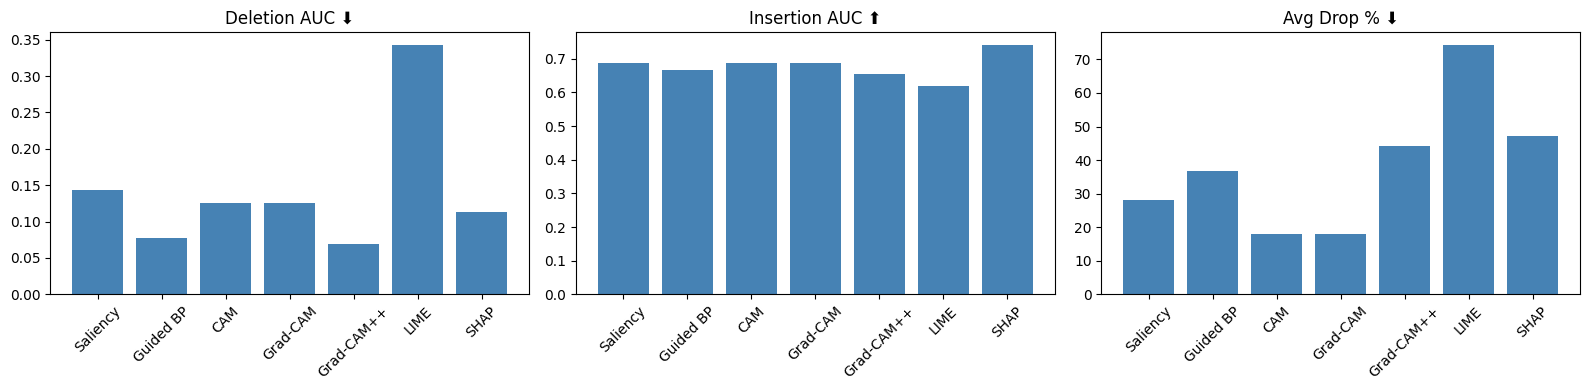

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, results.columns):
    ax.bar(results.index, results[col], color="steelblue")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()